# Connect And GetBlockchains

In [5]:
from circular_protocol_api import CircularProtocolAPI,helper

circular = CircularProtocolAPI()
result = circular.getBlockchains()
print(result)

{'Result': 200, 'Response': {'Blockchains': [{'Address': '714d2ac07a826b66ac56752eebd7c77b58d2ee842e523d913fd0ef06e6bdfcae', 'Name': 'Circular Main Public'}, {'Address': 'acb8a9b79f3c663aa01be852cd42725f9e0e497fd849b436df51c5e074ebeb28', 'Name': 'Circular Secondary Public'}, {'Address': 'e087257c48a949710b48bc725b8d90066871fa08f7bbe75d6b140d50119c481f', 'Name': 'Circular Documark Public'}, {'Address': '8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2', 'Name': 'Circular SandBox'}]}, 'Node': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4'}


 # GetWallet


In [3]:
circular.getWallet(blockchain="0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2", 
address="0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5")

{'Result': 200,
 'Response': {'Address': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
  'Assets': [{'Address': '',
    'Amount': '107.000000',
    'Description': 'Circular Coin',
    'EnableSwap': 0,
    'Name': 'CIRX',
    'Price': '1',
    'Royalties': '0',
    'Type': 'C_TYPE_COIN',
    'URL': '',
    'URLType': ''}],
  'ContractData': [],
  'DateCreation': '2025:08:07-09:56:45',
  'LatestTransactions': [{'Amount': 100.0,
    'Asset': 'CIRX',
    'BlockID': 43885,
    'ID': 'cab5e1f9110aa8d15a17d16ccd379a27300c553adcaa5b14f3e03e9837821cc2',
    'Timestamp': '2025:08:11-08:40:50',
    'Type': 'C_TRANSFER',
    'Wallet': '8b1dd25076c04c5139acba458f86c69cd2d322c61d19bc28daa3bbd945083738'},
   {'Amount': -15.5,
    'Asset': 'CIRX',
    'BlockID': 43886,
    'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
    'Timestamp': '2025:08:11-08:41:29',
    'Type': 'C_CERTIFICATE',
    'Wallet': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217

# GetAnalytics

In [3]:
circular.getAnalytics(blockchain="0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2")

{'Result': 200,
 'Response': {'Network_ID': 'Testnet',
  'Blockchain': '8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2',
  'Wallets': '5580',
  'SmartContracts': '94',
  'SmartContractsTx': '155',
  'Assets': '28',
  'CRC_0123': '18',
  'CRC_0223': '10',
  'CRC_0323': '0',
  'CRC_0XXX': '0',
  'Vouchers': '326',
  'OutVouchers': '143',
  'Transactions': '46239',
  'BroadcastingFees': '39304.000000',
  'TransactionFees': '0.000000',
  'Royalties': '0.000000',
  'CIRXTransfers': '2537044416.445542'},
 'Node': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4'}

# Try transactions

In [7]:
from circular_protocol_api import CircularProtocolAPI
from circular_protocol_api import helper
from circular_protocol_api import nag_functions
import json

circular = CircularProtocolAPI()

blockchain = "0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2"
sender ="0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5" 
to = sender # If the particular transaction doesn't necessitate a recipient address, this field can be the same as the sender's address.
privateKey = "0x136ddea8d5b1b5ee3ba3cc013831b71a7dc20ca1b11f3635795f07603ff611a6"

# --- 1. Dati del lotto (JSON) ---
payload = {
    "batch_id": "LOTTO-2025-08-001",
    "type": "raccolta",
    "product": "Latte crudo DOP",
    "quantity": 480,
    "unit": "litri",
    "location": "Parma",
    "timestamp": "2025-08-11T10:05:00Z",
    "parents": ["PARENT-LOTT12", "PARENT-LOTT34"],  # IDs lotti predecessori
    "certification": "DOP",
    "notes": "Raccolta mattutina, temperatura 4°C"
}

timestamp = helper.getFormattedTimestamp()
blockchain = helper.hexFix(blockchain)
nonce = int(circular.getWalletNonce(blockchain, sender)["Response"]["Nonce"]) + 1
payload = helper.hexFix(json.dumps(payload).encode().hex())
privateKey = helper.hexFix(privateKey)
sender = helper.hexFix(sender)
to = helper.hexFix(to)
ID = str(blockchain + sender + to + payload + str(nonce) + timestamp)

hashID = helper.sha256(ID)
signature = helper.signMessage(hashID, privateKey)
transactionType = "C_TYPE_CERTIFICATE"

'''C_TYPE_CERTIFICATE
Descrizione: Una transazione dove il payload è una stringa generica, tipicamente hashata, e non richiede elaborazione aggiuntiva né è rappresentata da un token.

Uso ideale: Per certificare un evento, uno step o un documento nella filiera senza bisogno di smart contract o asset tokenizzati.

Funziona così: Invii un payload (tipicamente la hash dei dati in JSON, oppure direttamente la stringa, se molto compatta), indicando i riferimenti parent (ID dei lotti precedenti se serve), timestamp, wallet dell’attore.

Vantaggi: È leggera, semplice e pensata proprio per le certificazioni nella supply chain, tracciabilità e attestazioni di processo che non hanno un valore token o asset diretto.'''

data = {
    'ID': hashID,
    'From': sender,
    'To': to,
    'Timestamp': timestamp,
    'Type': transactionType,
    'Payload': payload,
    'Nonce': f"{nonce}",
    'Signature': signature,
    'Blockchain': blockchain,
    'Version': circular.getVersion()
}
print(data)

result = helper.sendRequest(data, nag_functions._SEND_TRANSACTION, circular.getNAGURL())

{'ID': '5f3be47b3ccf12e428c46f2e37accd52220e4d10d8ac9a4c02ee53d1eef841e4', 'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5', 'To': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5', 'Timestamp': '2025:08:18-08:03:56', 'Type': 'C_TYPE_CERTIFICATE', 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c202263657274696669636174696f6e223a2022444f50222c20226e6f746573223a2022526163636f6c7461206d6174747574696e612c2074656d706572617475726120345c753030623043227d', 'Nonce': '7', 'Signature': '3045022100cd1b039c561b5beb1b13968a5d2eea4582bcfcd9e8e0e76632a7654a02

In [8]:
result

{'Result': 200,
 'Response': {'TxID': '5f3be47b3ccf12e428c46f2e37accd52220e4d10d8ac9a4c02ee53d1eef841e4',
  'Timestamp': '2025:08:18-08:03:56'},
 'Node': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4'}

In [13]:
tx_id=result["Response"]["TxID"]
tx_id

'5f3be47b3ccf12e428c46f2e37accd52220e4d10d8ac9a4c02ee53d1eef841e4'

# Get transactions

## by ID

In [16]:
txid=0x6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777
res= circular.getTransactionByID(blockchain,txid,"0","2") #start ed end?
res

{'Result': 200,
 'Response': {'BlockID': '43886',
  'BroadcastFee': 1.0,
  'DeveloperFee': 0.0,
  'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
  'GasLimit': 0.0,
  'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
  'Instructions': 0,
  'NagFee': 0.5,
  'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4',
  'Nonce': '1',
  'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66',
  'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e5

### Torno da HEX a STR

In [17]:
# Questo è il payload esadecimale ottenuto da getTransactionByID
payload_hex = res["Response"]["Payload"]

# 1. Converto da hex a bytes
payload_bytes = bytes.fromhex(payload_hex)

# 2. Converto i bytes in stringa UTF-8
payload_str = payload_bytes.decode("utf-8")

# 3. Converto la stringa in oggetto Python (dizionario) se è JSON
payload_json = json.loads(payload_str)

print("JSON originale della transazione:")
print(json.dumps(payload_json, indent=2, ensure_ascii=False))

JSON originale della transazione:
{
  "batch_id": "LOTTO-2025-08-001",
  "type": "raccolta",
  "product": "Latte crudo DOP",
  "quantity": 480,
  "unit": "litri",
  "location": "Parma",
  "timestamp": "2025-08-11T10:05:00Z",
  "parents": [
    "PARENT-LOTT12",
    "PARENT-LOTT34"
  ],
  "certification": "DOP",
  "notes": "Raccolta mattutina, temperatura 4°C"
}


## By address of sender

In [26]:
res=circular.getTransactionsByAddress(blockchain, sender, "0", "10")
res

{'Result': 200,
 'Response': [{'BlockID': '43886',
   'BroadcastFee': 1.0,
   'DeveloperFee': 0.0,
   'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
   'GasLimit': 0.0,
   'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
   'Instructions': 0,
   'NagFee': 0.5,
   'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4',
   'Nonce': '1',
   'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66',
   'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c202

In [32]:
type(res)
res.keys()
res["Response"][0]

{'BlockID': '43886',
 'BroadcastFee': 1.0,
 'DeveloperFee': 0.0,
 'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
 'GasLimit': 0.0,
 'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
 'Instructions': 0,
 'NagFee': 0.5,
 'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4',
 'Nonce': '1',
 'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66',
 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c2022636572746966696

## by Date and address 

In [ ]:
blockchain = "0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2"
wallet_address = "0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5"
start_date = "2025:07:12-11:59:11"
end_date = "2025:10:11-15:23:23"

result = circular.getTransactionByDate(blockchain, wallet_address, start_date, end_date)

print(result)


{'Result': 200, 'Response': [{'BroadcastFee': 1.0, 'DeveloperFee': 0.0, 'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5', 'GasLimit': 0.0, 'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777', 'Instructions': 0, 'NagFee': 0.5, 'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4', 'Nonce': '1', 'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66', 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c202263657274696669636

# RETRIEVE ENV VARS

In [ ]:
from dotenv import load_dotenv #pip install python-dotenv
import os

# Carica il file .env
load_dotenv()

blockchain=os.getenv("Blockchain")


0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2


## DB

In [5]:
import os
from dotenv import load_dotenv
import mysql.connector
from mysql.connector import Error

def connect_to_db():
    # Carica variabili dal file .env
    load_dotenv()

    # Recupera variabili ambiente
    host = os.getenv("MYSQL_HOST")
    port = int(os.getenv("MYSQL_PORT", 3306))
    user = os.getenv("MYSQL_USER")
    password = os.getenv("MYSQL_PASSWORD")
    database = os.getenv("MYSQL_DATABASE")
    try:
        # Connessione al database
        connection = mysql.connector.connect(
            host=host,
            port=port,
            user=user,
            password=password,
            database=database
        )

        if connection.is_connected():
            print("✅ Connessione al database avvenuta con successo!")
            cursor = connection.cursor()
            cursor.execute("SELECT DATABASE();")
            record = cursor.fetchone()
            print(f"📂 Database attuale: {record[0]}")
            cursor.execute("SELECT * FROM user;")
            rows = cursor.fetchall()
            print("👥 Utenti nel database:"f"\n{rows}")


    except Error as e:
        print(f"❌ Errore durante la connessione a MySQL: {e}")

    finally:
        if 'connection' in locals() and connection.is_connected():
            cursor.close()
            connection.close()
            print("🔌 Connessione chiusa.")

connect_to_db()


✅ Connessione al database avvenuta con successo!
📂 Database attuale: smartfood
👥 Utenti nel database:
[(1, 'Dom', 'Produttore', 'mimmo@gmail.com', '0x123', datetime.datetime(2025, 8, 12, 11, 15, 57), 1, 'ciao')]
🔌 Connessione chiusa.


# SERVER

# Decodifica da base4


In [19]:
import base64
from PIL import Image
from io import BytesIO
import os
import matplotlib.pyplot as plt
def show_qr_from_base64(img_base64: str):
    # Decodifica da base64 a bytes
    img_bytes = base64.b64decode(img_base64)

    # Carica l'immagine da buffer
    img = Image.open(BytesIO(img_bytes))


    # Mostra direttamente in una finestra matplotlib
    plt.imshow(img)
    plt.axis("off")
    plt.show()


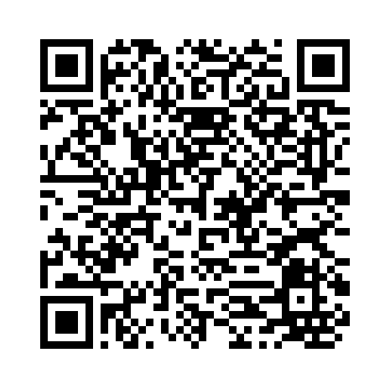

In [21]:
show_qr_from_base64("iVBORw0KGgoAAAANSUhEUgAAAeoAAAHqAQAAAADjFjCXAAAD+UlEQVR4nO2dTYqkShSFz30KNQyhFlBL0R30kopeUu8gXUotoCAcJkRy3iB+zez3Bipk23nuQNT0QwIu999II3bI/M8eGhAuXLhw4cKFCxd+LG5JegBLj3SGm2EebhYfmXAzYMmPTse9Xfir4SBJYiRJ+o68AIgH+o4AOvLiAgCXH6nE5dRrF/5sfEnmyz5JAo60yQXwgpvZ59cbyS9LVi9ZwgPfLvy18P7hzvIebPS3Pp0RwDzAOP/4TZHl1GsX/iz8Qeuihg3fANzViGUA4DwMMDzo3anXLvzZuGMM6QDHqFv8OXQ0+yAx+puRJG0CQDIc/Hbhr4WnbCJJR4z+/w/5UWUTwjdL9LCt53QBnIcuXc0fAYC7GoCbAW7tZE+9duHPwnPlxAMoVZK2VELmakqsnOTnKFsnfLMk9XGpBIeiUnfeNJ0VNysPK3y75Liua01aNHhIVeLodS+O8SyVlKV1wjdL22mIKhWyNy2p6shQDivVk9YJ3yTFbjV2LateiFWSZOYAJKunuE74Psk6V31o1r8x9mERo7mkhB6Ij8jWCd8uNXMgfQnzXEC8V8O8OAzgqhGU1gnfKKUj1gWDC/WSBhd6A/pgowdt/AUQy7qFduq1C38W3lROYtI61gId0KQPuYanuE74oVrHnEOkUl3UsDxpV5ywcljhh3hYA+LsHGz8eqMBAOcfHW307wHAzTh/EIAjLOa6R7xd+GviTeXkriMRHWnypiW5KE5YHlb4dslJa4nmSr461oCvtCpK1CcPK3yHJKvls0mL93zOJuACUMvHKPekdcK3S/KrJNvc1CVNrEOe6cxVFZXWCd8qWetKp9W3P9SUtmpn7JdJ64RvlzaV8O1HiW0LArVLsbaJp1678Gfh67iOpfvaNUpYp+pUrxN+ID4PN8NsPfjz42qkB2xydRggDq/TbEAeBjjw7cJfDH+cOYkFkmLNcr2uGTdpRttPvXbhz8Kx8qtt9/W+QNf4VcV1wvdJ1Lp2O5M0y3lfEU5h3toSnnrtwp+F3++uk91naUb4rhlZj8ioep3wfXJXr6tllHaCuNyrH+9I64Rvl6xh9U61cCVpKD8AgL5MFH74zMl6yK5qWIn1FNcJ34mX+ToAQBcYL11HA7oALF3AbADnCQCW94B58JqvE75HHrIJoOSwD8ZNfVjhR+BtXFfy1eRt6w6xANrpk1rIO/Xahf8x+Pj1RpuWHja5q/HirmafJNMOsfG7nav9F77z7cJfAn/cITZ+IxEALO80uI6Yh++e89QFzFMPA94U1wnfI3dx3Wp4vex4UiZSSpdWcZ3wHZK1CUDT+L/b4B9otj2B9q8Tvg83/XudcOHChQsXLlz4X4H/C8TttTEFFiW/AAAAAElFTkSuQmCC")